# All-slices prediction

This notebook generates a complete synthetic spatial-transcriptomics slice from three previously trained models:

1. a domain-label model;
2. a cell-type model conditional on domain and region-relative coordinates;
3. an all-slice three-dimensional negative-binomial gene-expression model.

Set `TARGET_SLICE` to either:

- an observed slice, such as `"A0"`–`"A12"`; or
- a virtual intermediate slice, such as `"A1.5"` or `"A2.5"`.

## 1. Coordinate system and section alignment

The notebook does **not** perform a new registration of the original sections. It assumes that `adata.obsm[spatial_key]` already contains aligned three-dimensional coordinates for all observed sections. Thus, the $x$- and $y$-coordinates of adjacent sections are directly comparable, while the $z$-coordinate records section depth.

For an observed target such as `"A6"`, the original A6 coordinates and library sizes are retained. Its domain labels, cell-type labels, and gene-expression counts are then newly generated from the saved models.

For a virtual target such as `"A1.5"`, the code uses A1 and A2 as the lower and upper sections. It constructs correspondence in both directions:

- Half of the virtual cells are initiated by sampling cells from A1 and matching each sampled A1 cell to its nearest A2 cell in the aligned $x$-$y$ space. 
- The other half are generated symmetrically by sampling cells from A2 and matching them to their nearest A1 cells.

The matched coordinates are linearly interpolated. For `"A1.5"`, the interpolation weight is $0.5$, so each new $x$-$y$ coordinate is the midpoint of an adjacent-section matched pair. The new $z$-coordinate is the midpoint of the median A1 and A2 depths. Using both directions prevents the geometry of only one section from dominating the virtual slice.

## 2. Number of cells in a virtual section

`VIRTUAL_N_CELLS` controls the number of simulated cells.

- With the current setting `VIRTUAL_N_CELLS = None`, the code uses the rounded mean of the cell counts in the two adjacent observed sections.
- To generate exactly 5,000 cells, set `VIRTUAL_N_CELLS = 5000`.

For 5,000 cells, 2,500 cells are initiated from the lower section and 2,500 from the upper section. Each sampled cell is paired with its nearest neighbor in the other section before interpolation.

Five thousand is a practical simulation size, not a theoretically required number. It is usually large enough to preserve tissue geometry and local spatial patterns while keeping domain prediction, cell-type prediction, all-gene negative-binomial sampling, plotting, and storage manageable. When adjacent sections have substantially different cell counts, the current `None` setting is preferable because it automatically uses their average density.

Library size is interpolated between matched cells on the log scale. This preserves positivity and reflects the multiplicative variability of sequencing depth.

## 3. Domain-label generation

The saved domain MLP receives the three-dimensional coordinates after applying the scaler learned during domain-model training. The network produces one score for each domain. The largest score is selected, and the saved label encoder maps the class index back to the original domain label.

Thus, even for an observed target slice, `pred_region` is newly predicted rather than copied from an annotation.

## 4. Cell-type-label generation

For each predicted domain, the code uses the corresponding PCA transformation and coordinate scaling saved during cell-type-model training. The cell's three-dimensional position is transformed into region-relative PCA coordinates and scaled to $[-1,1]$. These three relative coordinates are concatenated with a one-hot encoding of the predicted domain.

The saved cell-type MLP returns a probability vector over cell types. A categorical draw using `SEED` converts these probabilities into one simulated cell-type label per cell. Therefore, `pred_celltype` is sampled from the model rather than assigned by the maximum-probability class.

## 5. Gene-expression generation

The all-slice gene-expression model is shared across all observed sections and uses a continuous three-dimensional spatial representation. For the target coordinates, the code:

1. standardizes $x,y,z$ using the saved training means and standard deviations;
2. evaluates the saved three-dimensional radial-basis functions;
3. constructs the design matrix from the intercept, simulated cell-type indicators, simulated domain indicators, and spatial RBF values;
4. uses the target-cell library size as a log offset.

For gene $g$,

$$
\log \mu_{ig}
=
\log L_i + X_i^\top\widehat\beta_g,
$$

and the synthetic count is sampled as

$$
Y_{ig}^{\mathrm{sim}}
\sim
\operatorname{NB}
\left(
\mu_{ig},
\widehat\alpha_g
\right).
$$

The saved `.h5ad` contains sampled counts, not fitted expected values. The displayed gene map also shows `log1p` of one sampled synthetic count realization.

## 6. Outputs

The notebook saves:

- `<TARGET_SLICE>_synthetic.h5ad`, containing coordinates, library sizes, predicted domains, sampled cell types, cell-type probabilities, and sampled gene counts;
- `<TARGET_SLICE>_synthetic.png`, showing the simulated domain map, cell-type map, and selected gene's sampled expression.


In [17]:
from pathlib import Path
import re
import pickle
import joblib

import numpy as np
import pandas as pd
import anndata as ad
import scanpy as sc
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap

import torch
import torch.nn as nn

from scipy.sparse import csr_matrix
from sklearn.neighbors import NearestNeighbors


TARGET_SLICE = "A2"       # A0-A12, or A0.5-A11.5
PLOT_GENE = "Nnat"
SEED = 20260623
VIRTUAL_N_CELLS = None

ADATA_PATH = Path("../adata_backup_with_pred_region_celltype.h5ad")
MODEL_DIR = Path("../saved_models")

DOMAIN_STATE = MODEL_DIR / "domain_mlp_state.pt"
DOMAIN_PREP = MODEL_DIR / "domain_preprocess.joblib"
CELLTYPE_STATE = MODEL_DIR / "celltype_mlp_state.pt"
CELLTYPE_PREP = MODEL_DIR / "celltype_preprocess.joblib"
GENE_MODEL = MODEL_DIR / "gene_fit_results_all_slices_3d.pkl"

OUT_DIR = Path("All_slices_prediction_outputs") / TARGET_SLICE
OUT_DIR.mkdir(parents=True, exist_ok=True)

In [18]:
class SpatialMLP(nn.Module):
    def __init__(self, input_dim, num_classes):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 256),
            nn.ReLU(),
            nn.Linear(256, 256),
            nn.ReLU(),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Linear(128, num_classes),
        )

    def forward(self, x):
        return self.net(x)


class SpatialProbMLP(nn.Module):
    def __init__(self, input_dim, n_celltypes):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 256),
            nn.ReLU(),
            nn.BatchNorm1d(256),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.BatchNorm1d(128),
            nn.Linear(128, n_celltypes),
        )

    def forward(self, x):
        return torch.softmax(self.net(x), dim=1)


def load_state(path):
    try:
        return torch.load(
            path,
            map_location="cpu",
            weights_only=True,
        )
    except TypeError:
        return torch.load(path, map_location="cpu")


def interpolate_virtual_slice(
    lower,
    upper,
    weight,
    spatial_key,
    n_cells,
    seed,
):
    rng = np.random.default_rng(seed)

    xyz0 = np.asarray(
        lower.obsm[spatial_key][:, :3],
        dtype=float,
    )
    xyz1 = np.asarray(
        upper.obsm[spatial_key][:, :3],
        dtype=float,
    )
    size0 = lower.obs["size"].to_numpy(dtype=float)
    size1 = upper.obs["size"].to_numpy(dtype=float)

    n = (
        int(round((len(lower) + len(upper)) / 2))
        if n_cells is None
        else int(n_cells)
    )
    n0 = n // 2
    n1 = n - n0

    pick0 = rng.choice(len(lower), n0, replace=n0 > len(lower))
    near1 = NearestNeighbors(n_neighbors=1).fit(
        xyz1[:, :2]
    ).kneighbors(
        xyz0[pick0, :2],
        return_distance=False,
    ).ravel()

    pick1 = rng.choice(len(upper), n1, replace=n1 > len(upper))
    near0 = NearestNeighbors(n_neighbors=1).fit(
        xyz0[:, :2]
    ).kneighbors(
        xyz1[pick1, :2],
        return_distance=False,
    ).ravel()

    xy = np.vstack([
        (1.0 - weight) * xyz0[pick0, :2]
        + weight * xyz1[near1, :2],
        (1.0 - weight) * xyz0[near0, :2]
        + weight * xyz1[pick1, :2],
    ])
    z = (
        (1.0 - weight) * np.median(xyz0[:, 2])
        + weight * np.median(xyz1[:, 2])
    )
    xyz = np.c_[xy, np.full(n, z)]

    log_size = np.r_[
        (1.0 - weight) * np.log(np.maximum(size0[pick0], 1e-8))
        + weight * np.log(np.maximum(size1[near1], 1e-8)),
        (1.0 - weight) * np.log(np.maximum(size0[near0], 1e-8))
        + weight * np.log(np.maximum(size1[pick1], 1e-8)),
    ]

    return xyz, np.exp(log_size)


def make_target_slice(adata, label, spatial_key):
    value = float(
        re.fullmatch(r"A(\d+(?:\.5)?)", label).group(1)
    )

    if value.is_integer():
        source = adata[
            adata.obs["batch"].astype(str)
            == f"A{int(value)}"
        ].copy()
        return (
            np.asarray(
                source.obsm[spatial_key][:, :3],
                dtype=float,
            ),
            source.obs["size"].to_numpy(dtype=float),
        )

    lower = adata[
        adata.obs["batch"].astype(str)
        == f"A{int(np.floor(value))}"
    ].copy()
    upper = adata[
        adata.obs["batch"].astype(str)
        == f"A{int(np.ceil(value))}"
    ].copy()

    return interpolate_virtual_slice(
        lower,
        upper,
        value - np.floor(value),
        spatial_key,
        VIRTUAL_N_CELLS,
        SEED,
    )

In [19]:
adata = sc.read(ADATA_PATH)

domain_prep = joblib.load(DOMAIN_PREP)
domain_model = SpatialMLP(
    int(domain_prep["input_dim"]),
    int(domain_prep["num_classes"]),
)
domain_model.load_state_dict(load_state(DOMAIN_STATE))
domain_model.eval()

cell_prep = joblib.load(CELLTYPE_PREP)
cell_categories = list(map(str, cell_prep["region_categories"]))
celltype_names = np.asarray([
    str(name).replace("prob_", "")
    for name in cell_prep["prob_cols"]
])
cell_transforms = {
    str(region): transform
    for region, transform in cell_prep[
        "region_coordinate_transforms"
    ].items()
}

cell_model = SpatialProbMLP(
    int(cell_prep["input_dim"]),
    int(cell_prep["n_celltypes"]),
)
cell_model.load_state_dict(load_state(CELLTYPE_STATE))
cell_model.eval()

spatial_key = str(domain_prep["spatial_key"])
xyz, library_size = make_target_slice(
    adata,
    TARGET_SLICE,
    spatial_key,
)

with torch.no_grad():
    region_index = domain_model(
        torch.tensor(
            domain_prep["scaler"].transform(xyz),
            dtype=torch.float32,
        )
    ).argmax(dim=1).cpu().numpy()

regions = domain_prep[
    "label_encoder"
].inverse_transform(region_index).astype(str)

relative = np.zeros((len(xyz), 3), dtype=float)

for region in np.unique(regions):
    mask = regions == region
    transform = cell_transforms[region]
    projected = (
        xyz[mask]
        if transform["pca"] is None
        else transform["pca"].transform(xyz[mask])
    )
    span = np.where(
        np.asarray(transform["scale"]) < 1e-6,
        1.0,
        np.asarray(transform["scale"]),
    )
    relative[mask] = np.clip(
        2.0 * (
            projected - np.asarray(transform["min_xyz"])
        ) / span - 1.0,
        -1.0,
        1.0,
    )

region_onehot = np.zeros(
    (len(xyz), len(cell_categories)),
    dtype=float,
)
category_index = {
    region: j
    for j, region in enumerate(cell_categories)
}
for i, region in enumerate(regions):
    region_onehot[i, category_index[region]] = 1.0

with torch.no_grad():
    celltype_probability = cell_model(
        torch.tensor(
            np.c_[relative, region_onehot],
            dtype=torch.float32,
        )
    ).cpu().numpy()

rng = np.random.default_rng(SEED)
uniforms = rng.random(len(xyz))
celltype_index = (
    uniforms[:, None]
    > np.cumsum(celltype_probability, axis=1)
).sum(axis=1)
celltypes = celltype_names[
    np.minimum(celltype_index, len(celltype_names) - 1)
]

In [20]:
with open(GENE_MODEL, "rb") as handle:
    gene_model = pickle.load(handle)

genes = list(map(str, gene_model["genes"]))
columns = list(map(str, gene_model["X_columns"]))
basis = gene_model["basis_info"]

xyz_std = (
    xyz - np.asarray(basis["coord_mean"])
) / (
    np.asarray(basis["coord_sd"]) + 1e-8
)
distance2 = np.sum(
    (
        xyz_std[:, None, :]
        - np.asarray(basis["centers"])[None, :, :]
    ) ** 2,
    axis=2,
)
rbf = np.exp(
    -0.5
    * distance2
    / float(basis["bandwidth"]) ** 2
)

X = np.zeros((len(xyz), len(columns)), dtype=float)

for j, name in enumerate(columns):
    if name == "Intercept":
        X[:, j] = 1.0
    elif name.startswith("celltype_"):
        X[:, j] = (
            celltypes == name[len("celltype_"):]
        )
    elif name.startswith("domain_"):
        X[:, j] = (
            regions == name[len("domain_"):]
        )
    elif name.startswith("spatial_rbf_"):
        X[:, j] = rbf[
            :,
            int(name.rsplit("_", 1)[1]) - 1,
        ]

offset = np.log(np.maximum(library_size, 1e-8))
counts = np.zeros((len(xyz), len(genes)), dtype=np.int32)

for j, gene in enumerate(genes):
    fit = gene_model["fits"].get(gene)
    if fit is None:
        continue

    beta = np.asarray(fit["beta"], dtype=float)
    alpha = max(float(fit["alpha"]), 1e-8)
    mu = np.exp(
        np.clip(X @ beta + offset, -20, 20)
    )

    size = 1.0 / alpha
    probability = np.clip(
        size / (size + mu),
        1e-12,
        1.0 - 1e-12,
    )
    counts[:, j] = np.random.default_rng(
        SEED + j
    ).negative_binomial(
        size,
        probability,
    ).astype(np.int32)

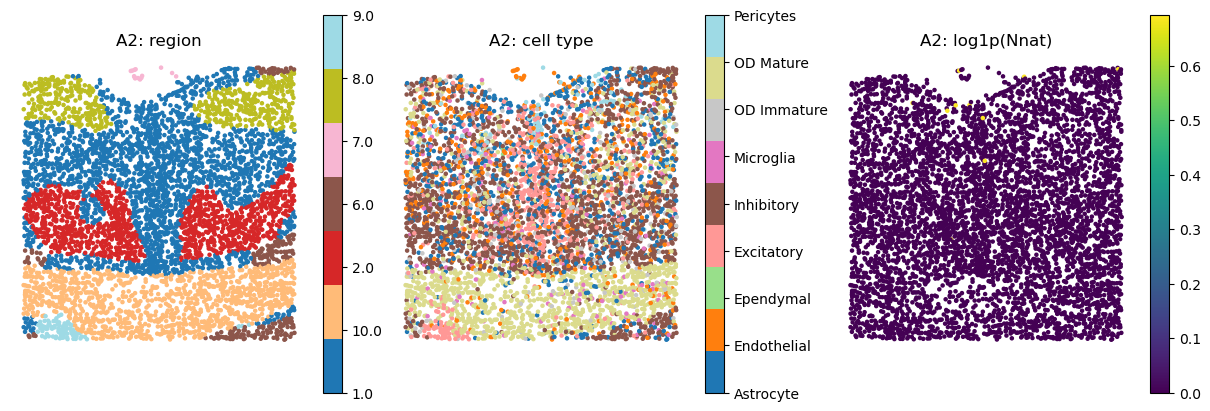

Saved to: /Users/yyq/Documents/MyDocuments/project/吴浩老师 3d ST simulator/code/20260525 志伟源代码+原始数据/code_add_info/All_slices_prediction_outputs/A2


In [21]:
obs = pd.DataFrame(
    {
        "batch": TARGET_SLICE,
        "x": xyz[:, 0],
        "y": xyz[:, 1],
        "z": xyz[:, 2],
        "size": library_size,
        "pred_region": regions,
        "pred_celltype": celltypes,
    },
    index=[
        f"{TARGET_SLICE}_synthetic_{i}"
        for i in range(len(xyz))
    ],
)

synthetic = ad.AnnData(
    X=csr_matrix(counts),
    obs=obs,
    var=adata[:, genes].var.copy(),
)
synthetic.layers["counts"] = synthetic.X.copy()
synthetic.obsm["spatial"] = xyz[:, :2].copy()
synthetic.obsm["spatial_3d"] = xyz.copy()
synthetic.obsm["pred_celltype_proba"] = (
    celltype_probability.astype(np.float32)
)
synthetic.uns["pred_celltype_names"] = (
    celltype_names.astype(str)
)

synthetic.write_h5ad(
    OUT_DIR / f"{TARGET_SLICE}_synthetic.h5ad"
)

region_levels = sorted(pd.unique(regions))
cell_levels = sorted(pd.unique(celltypes))
gene_values = np.log1p(
    counts[:, genes.index(PLOT_GENE)]
)

fig, axes = plt.subplots(
    1,
    3,
    figsize=(12, 4),
    constrained_layout=True,
)

sr = axes[0].scatter(
    xyz[:, 0],
    xyz[:, 1],
    c=pd.Categorical(
        regions,
        categories=region_levels,
    ).codes,
    s=5,
    cmap=ListedColormap(
        plt.cm.tab20(
            np.linspace(0, 1, len(region_levels))
        )
    ),
)
scell = axes[1].scatter(
    xyz[:, 0],
    xyz[:, 1],
    c=pd.Categorical(
        celltypes,
        categories=cell_levels,
    ).codes,
    s=5,
    cmap=ListedColormap(
        plt.cm.tab20(
            np.linspace(0, 1, len(cell_levels))
        )
    ),
)
sgene = axes[2].scatter(
    xyz[:, 0],
    xyz[:, 1],
    c=gene_values,
    s=5,
    cmap="viridis",
)

axes[0].set_title(f"{TARGET_SLICE}: region")
axes[1].set_title(f"{TARGET_SLICE}: cell type")
axes[2].set_title(f"{TARGET_SLICE}: log1p({PLOT_GENE})")

for axis in axes:
    axis.set_aspect("equal")
    axis.invert_yaxis()
    axis.axis("off")

region_bar = fig.colorbar(
    sr,
    ax=axes[0],
    ticks=np.arange(len(region_levels)),
)
region_bar.ax.set_yticklabels(region_levels)

cell_bar = fig.colorbar(
    scell,
    ax=axes[1],
    ticks=np.arange(len(cell_levels)),
)
cell_bar.ax.set_yticklabels(cell_levels)

fig.colorbar(sgene, ax=axes[2])

plt.savefig(
    OUT_DIR / f"{TARGET_SLICE}_synthetic.png",
    dpi=220,
    bbox_inches="tight",
)
plt.show()

print("Saved to:", OUT_DIR.resolve())